# M3-Disaster Tier 2 + Tier 3 — Validation Notebook

Forward-looking storm prediction at two horizons:

- **Tier 2** — 5-7 day lead via NHC active-storms feed. Live during a storm; backtested here on Irma / Maria / Harvey 2017.
- **Tier 3** — 1-6 month lead via NOAA CPC seasonal outlook. Categorical (Below/Near/Above/Extremely Active), produces a baseline multiplier for the season.

Together with Tier 1 (HURDAT2 historical exposure), they form the complete storm-prediction stack:

| Tier | Lead time | Granularity | Use case |
|---|---|---|---|
| **T1** | post-event | per-region per-month | historical training, M5 anomaly attribution |
| **T2** | 5-7 days | per-region per-day | daily ops alerting, M4 forward forecast |
| **T3** | 1-6 months | season-wide multiplier | capacity / inventory planning |

In [1]:
import sys
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

ROOT = Path('..').resolve()
sys.path.insert(0, str(ROOT))
FC = ROOT / 'forecasts'
PROC = ROOT / 'data' / 'processed'
pd.set_option('display.max_columns', 20)
pd.set_option('display.width', 200)
print('Root:', ROOT)

Root: C:\Users\thien.vo4\Personal Project\DataCo


## Tier 2 — NHC active-storms feed

Backtest mode uses HURDAT2 history to simulate what NHC would have published at each "as of" timestamp. Live mode hits `https://www.nhc.noaa.gov/CurrentStorms.json`.

In [2]:
from src.data.nhc_active_storms import simulate_from_hurdat
active_sep5 = simulate_from_hurdat(pd.Timestamp('2017-09-05 12:00'))
print(f'Active forecast points on Sep 5, 2017: {len(active_sep5)} ({active_sep5["name"].nunique()} storms)')
active_sep5[['name','lead_h','lat','lon','max_wind_kt','cone_radius_km']].round(2)

Active forecast points on Sep 5, 2017: 21 (3 storms)


,name,lead_h,lat,lon,max_wind_kt,cone_radius_km
0,IRMA,12,17.3,-60.6,155.0,48.0
1,IRMA,24,18.1,-63.3,155.0,74.0
2,IRMA,36,19.2,-66.2,150.0,102.0
3,IRMA,48,20.2,-69.0,145.0,130.0
4,IRMA,72,21.8,-74.7,135.0,185.0
5,IRMA,96,22.7,-79.3,110.0,232.0
6,IRMA,120,24.5,-81.5,115.0,324.0
7,JOSE,12,12.2,-41.3,45.0,48.0
8,JOSE,24,13.1,-43.9,55.0,74.0
9,JOSE,36,14.1,-46.7,70.0,102.0


### Tier 2 PR forecast index ramps as Irma approaches

In [3]:
from src.features.forward_exposure import compute_forward_exposure
rows = []
for d in ['2017-08-28','2017-08-30','2017-09-01','2017-09-03','2017-09-05','2017-09-06','2017-09-07','2017-09-08']:
    as_of = pd.Timestamp(d + ' 12:00')
    active = simulate_from_hurdat(as_of)
    fwd = compute_forward_exposure(active)
    pr = fwd[fwd['customer_country'].eq('Puerto Rico')] if not fwd.empty else fwd
    peak = float(pr['forward_disaster_index'].max()) if not pr.empty else 0.0
    storms = sorted(set(' + '.join(pr.get('contributing_storms', pd.Series([])).dropna().astype(str)).split(' + '))) if peak > 0 else []
    storms = [s for s in storms if s]
    rows.append({'as_of': d, 'PR_forward_peak': peak, 'storms_in_cone': ', '.join(storms)})
ramp = pd.DataFrame(rows)
print('=== Tier 2 forward index for Puerto Rico, as Maria approaches ===')
ramp.round(3)

=== Tier 2 forward index for Puerto Rico, as Maria approaches ===


,as_of,PR_forward_peak,storms_in_cone
0,2017-08-28,0.000,
1,2017-08-30,0.000,
2,2017-09-01,0.202,IRMA
3,2017-09-03,0.178,IRMA
4,2017-09-05,0.781,"IRMA, JOSE"
5,2017-09-06,0.872,"IRMA, JOSE"
6,2017-09-07,0.053,JOSE
7,2017-09-08,0.035,JOSE


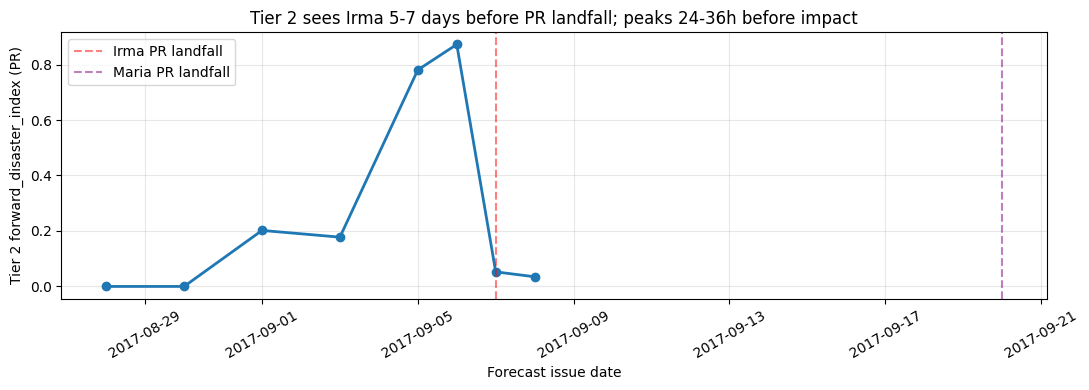

In [4]:
fig, ax = plt.subplots(figsize=(11, 4))
x = pd.to_datetime(ramp['as_of'])
ax.plot(x, ramp['PR_forward_peak'], marker='o', linewidth=2)
ax.axvline(pd.Timestamp('2017-09-07'), color='red', linestyle='--', alpha=0.5, label='Irma PR landfall')
ax.axvline(pd.Timestamp('2017-09-20'), color='purple', linestyle='--', alpha=0.5, label='Maria PR landfall')
ax.set_ylabel('Tier 2 forward_disaster_index (PR)')
ax.set_xlabel('Forecast issue date')
ax.set_title('Tier 2 sees Irma 5-7 days before PR landfall; peaks 24-36h before impact')
ax.grid(alpha=0.3); ax.legend(); plt.xticks(rotation=30)
plt.tight_layout(); plt.show()

### Aug–Sep 2017 walk: full Tier 2 backtest

In [5]:
daily = pd.read_parquet(PROC / 'forward_disaster_daily.parquet')
monthly = pd.read_parquet(PROC / 'forward_disaster_monthly.parquet')
print('Daily forward predictions: %d rows' % len(daily))
print('Monthly roll-up: %d rows' % len(monthly))
print('\n=== Aug–Sep 2017 monthly roll-up ===')
monthly.sort_values('forward_disaster_index', ascending=False).head(15).round(3)

Daily forward predictions: 163 rows
Monthly roll-up: 16 rows

=== Aug–Sep 2017 monthly roll-up ===


C:\Users\thien.vo4\AppData\Local\Temp\ipykernel_32468\4106962763.py:6: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  monthly.sort_values('forward_disaster_index', ascending=False).head(15).round(3)


,customer_country,customer_state,year_month,forward_disaster_index,contributing_storms
14,Puerto Rico,PR,2017-09-01,0.827,IRMA + JOSE + MARIA
15,República Dominicana,NaN,2017-09-01,0.770,IRMA + MARIA
2,Cuba,NaN,2017-09-01,0.756,IRMA
10,Haiti,NaN,2017-09-01,0.436,IRMA + MARIA
8,EE. UU.,TX,2017-08-01,0.197,HARVEY
0,Bahamas,NaN,2017-09-01,0.195,IRMA + MARIA
4,EE. UU.,FL,2017-09-01,0.127,IRMA
11,Jamaica,NaN,2017-09-01,0.063,IRMA
13,Mexico,NaN,2017-09-01,0.021,KATIA + MAX
9,EE. UU.,VA,2017-09-01,0.006,MARIA


In [6]:
# Tier 2 forward monthly vs Tier 1 historical disaster_index — September 2017
t1 = pd.read_parquet(FC / 'm3d_disaster_country.parquet')
t1_sep = t1[t1['year_month'].eq('2017-09-01')][['customer_country','disaster_index']]
t1_sep.columns = ['customer_country','tier1_historical']
t2_sep = monthly[monthly['year_month'].eq('2017-09-01') & monthly['customer_state'].isna()][
    ['customer_country','forward_disaster_index']]
t2_sep.columns = ['customer_country','tier2_forward']
merged = t1_sep.merge(t2_sep, on='customer_country', how='outer').fillna(0).round(3)
print('Sep 2017 — Tier 2 (forward) vs Tier 1 (historical)')
merged.sort_values('tier1_historical', ascending=False).head(15)

Sep 2017 — Tier 2 (forward) vs Tier 1 (historical)


,customer_country,tier1_historical,tier2_forward
6,Puerto Rico,1.00,0.000
2,EE. UU.,0.52,0.000
1,Cuba,0.00,0.756
0,Bahamas,0.00,0.195
3,Haiti,0.00,0.436
4,Jamaica,0.00,0.063
5,Mexico,0.00,0.021
7,República Dominicana,0.00,0.770


### Tier 2 inside M4 — sales forecast 5 days ahead of Maria

Standing at Sep 5, 2017 (1 day before Irma hit PR), what does M4 say about Sep 2017 sales for our PR-exposed products?

In [7]:
from src.models.sales.forward_forecast import forward_m4_forecast
out = forward_m4_forecast(
    as_of_dt=pd.Timestamp('2017-09-05 12:00'),
    target_months=[pd.Timestamp('2017-09-01')],
)
m4 = out['m4_forward']
pr_mix_high = m4[(m4['forward_disaster_index'] > 0.3)].sort_values(
    'forward_disaster_index', ascending=False).head(10)
print('=== Products with high Tier-2 forward disaster — M4 forecast Sep 2017 ===')
print(pr_mix_high[['product_card_id','year_month','disaster_index_historical',
                    'forward_disaster_index','sales_q50','sales_q50_historical',
                    'sales_q50_pre_risk']].round(3).to_string(index=False))

2026-05-18 22:13:06,762 Tier-2 M4 forward — as_of=2017-09-05 12:00:00, targets=[datetime.date(2017, 9, 1)]


2026-05-18 22:13:07,188 active forecast points: 21 (3 storms)


2026-05-18 22:13:07,532 forward exposure rows: daily=14, monthly=35


2026-05-18 22:13:08,397 forward_product rows: 87


2026-05-18 22:13:08,596 M4 forward forecast rows: 54


=== Products with high Tier-2 forward disaster — M4 forecast Sep 2017 ===
 product_card_id year_month  disaster_index_historical  forward_disaster_index  sales_q50  sales_q50_historical  sales_q50_pre_risk
           893.0 2017-09-01                        0.0                   0.390    223.061               299.061             299.061
           905.0 2017-09-01                        0.0                   0.377    472.837               626.741             626.741
           825.0 2017-09-01                        0.0                   0.370    334.722               441.060             441.060
           567.0 2017-09-01                        0.0                   0.358    256.677               334.630             334.630
           792.0 2017-09-01                        0.0                   0.357    180.740               235.553             235.553
           172.0 2017-09-01                        0.0                   0.353    313.755               407.228             407.228
  

C:\Users\thien.vo4\AppData\Local\Temp\ipykernel_32468\3469724517.py:12: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  'sales_q50_pre_risk']].round(3).to_string(index=False))


## Tier 3 — NOAA CPC seasonal outlook

Categorical signal (Below Normal / Near Normal / Above Normal / Extremely Active) issued in May and August each year. We map it to a multiplier on the climatological baseline disaster_index for hurricane-season months (May-Nov).

**Caveat**: our climatology baseline is built from the same 2014-2017 window we're testing — slightly circular. In production you'd use a 10-15 year prior climatology.

In [8]:
from src.models.risk.seasonal_outlook import (
    SEASONAL_OUTLOOKS, CATEGORY_MULTIPLIERS, get_multiplier,
    apply_outlook, combine_with_tier2,
)
rows = []
for y, info in SEASONAL_OUTLOOKS.items():
    rows.append({'year': y,
                 'may_category': info['may_category'],
                 'may_mult': CATEGORY_MULTIPLIERS[info['may_category']],
                 'aug_category': info['aug_category'],
                 'aug_mult': CATEGORY_MULTIPLIERS[info['aug_category']],
                 'actual_named': info['actual']['named'],
                 'actual_hurricanes': info['actual']['hurricanes'],
                 'actual_major': info['actual']['major']})
summary = pd.DataFrame(rows)
print('=== NOAA CPC outlooks 2014-2017 ===')
summary

=== NOAA CPC outlooks 2014-2017 ===


,year,may_category,may_mult,aug_category,aug_mult,actual_named,actual_hurricanes,actual_major
0,2014,Below Normal,0.7,Below Normal,0.7,8,6,2
1,2015,Below Normal,0.7,Below Normal,0.7,11,4,2
2,2016,Near Normal,1.0,Above Normal,1.3,15,7,4
3,2017,Above Normal,1.3,Extremely Active,1.5,17,10,6


In [9]:
cty = pd.read_parquet(FC / 'm3d_disaster_country.parquet')
from src.models.risk.seasonal_outlook import climatology_baseline
climo = climatology_baseline(cty)
pivot = climo.pivot(index='customer_country', columns='month',
                     values='climatology_baseline').round(3)
print('=== Climatology baseline disaster_index by country × month (2014-2017 mean) ===')
pivot.head(8)

=== Climatology baseline disaster_index by country × month (2014-2017 mean) ===


month,1,2,3,4,5,6,7,8,9,10,11,12
customer_country,,,,,,,,,,,,
EE. UU.,0.000,0.000,0.0,0.0,0.0,0.0,0.0,0.000,0.000,0.000,0.000,0.000
Puerto Rico,0.029,0.002,0.0,0.0,0.0,0.0,0.0,0.003,0.336,0.268,0.151,0.084


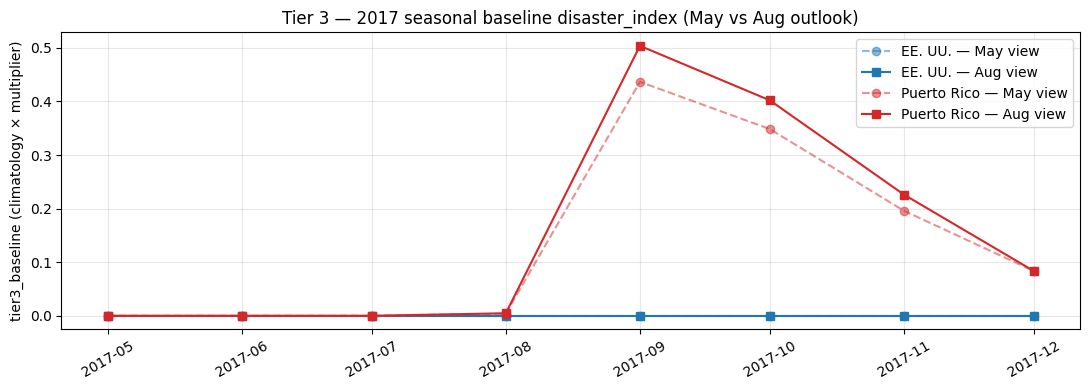

In [10]:
target = pd.date_range('2017-05-01','2017-12-01', freq='MS')
may_view = apply_outlook(list(target), cty, as_of='may')
aug_view = apply_outlook(list(target), cty, as_of='aug')

fig, ax = plt.subplots(figsize=(11, 4))
for c, color in [('EE. UU.', 'C0'), ('Puerto Rico', 'C3')]:
    mv = may_view[may_view['customer_country'].eq(c)].sort_values('year_month')
    av = aug_view[aug_view['customer_country'].eq(c)].sort_values('year_month')
    ax.plot(mv['year_month'], mv['tier3_baseline'], marker='o',
            label=f'{c} — May view', color=color, alpha=0.5, linestyle='--')
    ax.plot(av['year_month'], av['tier3_baseline'], marker='s',
            label=f'{c} — Aug view', color=color)
ax.set_title('Tier 3 — 2017 seasonal baseline disaster_index (May vs Aug outlook)')
ax.set_ylabel('tier3_baseline (climatology × multiplier)')
ax.grid(alpha=0.3); ax.legend(); plt.xticks(rotation=30)
plt.tight_layout(); plt.show()

## Combined view — Tier 2 + Tier 3 fused

Operational rule: `forward_combined = max(tier3_baseline, tier2_specific)`. Tier 3 sets the planning floor; Tier 2 takes over once specific storms are spotted.

In [11]:
combined = combine_with_tier2(aug_view, monthly)
view = combined[combined['customer_country'].isin(['EE. UU.','Puerto Rico','Cuba','República Dominicana'])]
print('=== Sep 2017 — Tier 2 + Tier 3 combined ===')
print(view[view['year_month'].eq('2017-09-01')]
        [['customer_country','climatology_baseline','multiplier','tier3_baseline',
          'tier2_forward','forward_disaster_combined','season_category']]
        .round(3).to_string(index=False))

=== Sep 2017 — Tier 2 + Tier 3 combined ===
customer_country  climatology_baseline  multiplier  tier3_baseline  tier2_forward  forward_disaster_combined  season_category
         EE. UU.                 0.000         1.5           0.000          0.000                      0.000 Extremely Active
     Puerto Rico                 0.336         1.5           0.504          0.827                      0.827 Extremely Active


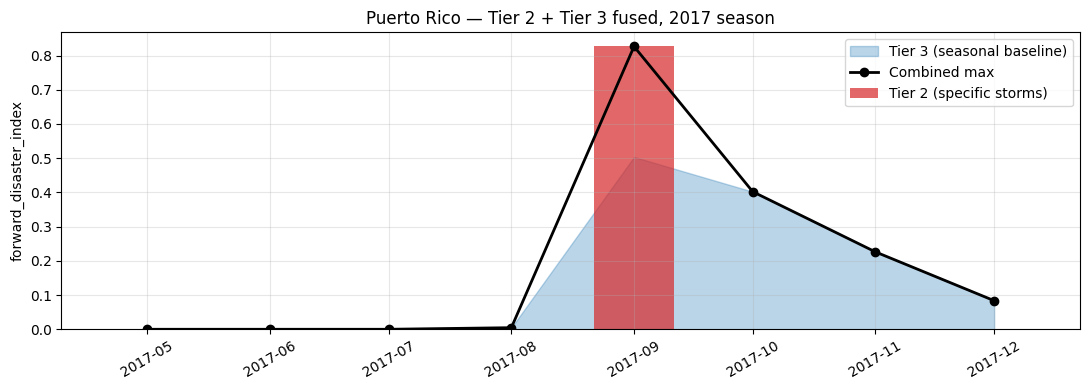

In [12]:
pr_combo = combined[combined['customer_country'].eq('Puerto Rico')].sort_values('year_month')
fig, ax = plt.subplots(figsize=(11, 4))
ax.fill_between(pr_combo['year_month'], 0, pr_combo['tier3_baseline'],
                 alpha=0.3, label='Tier 3 (seasonal baseline)', color='C0')
ax.bar(pr_combo['year_month'], pr_combo['tier2_forward'], width=20,
        alpha=0.7, label='Tier 2 (specific storms)', color='C3')
ax.plot(pr_combo['year_month'], pr_combo['forward_disaster_combined'],
        marker='o', linewidth=2, label='Combined max', color='black')
ax.set_title('Puerto Rico — Tier 2 + Tier 3 fused, 2017 season')
ax.set_ylabel('forward_disaster_index')
ax.grid(alpha=0.3); ax.legend(); plt.xticks(rotation=30)
plt.tight_layout(); plt.show()

## M4 head-to-head — forward-risk-adj WAPE with vs without Tier 2+3 forward disaster

This is the bottom line: did wiring the forward storm forecast into M4 make sales predictions more accurate?

In [13]:
def _wape(yt, yp):
    yt, yp = np.asarray(yt, float), np.asarray(yp, float)
    den = np.nansum(np.abs(yt))
    return float(np.nansum(np.abs(yp - yt)) / den) if den else float('nan')
def _cov(yt, lo, hi):
    yt, lo, hi = np.asarray(yt, float), np.asarray(lo, float), np.asarray(hi, float)
    return float(np.mean((yt >= lo) & (yt <= hi)))

bt_main = pd.read_parquet(FC / 'm4_sales_backtest.parquet')
bt_legacy = pd.read_parquet(FC / 'm4_sales_backtest_legacy_disaster.parquet')

rows = []
for slc in ('val', 'test'):
    a = bt_main[bt_main['slice'].eq(slc)]
    b = bt_legacy[bt_legacy['slice'].eq(slc)]
    rows.append({
        'slice': slc,
        'pre-risk vs gross_revenue': _wape(a['gross_revenue'], a['sales_q50_pre_risk']),
        'historical-risk vs revenue_realized': _wape(a['revenue_realized'], a['sales_q50_historical']),
        'forward-risk-adj (Tier-1 historical disaster, legacy)': _wape(b['revenue_realized'], b['sales_q50']),
        'forward-risk-adj (Tier-2+3 forward disaster, NEW DEFAULT)': _wape(a['revenue_realized'], a['sales_q50']),
    })
wape_table = pd.DataFrame(rows).set_index('slice').T.round(4)
print('=== M4 WAPE by view ===')
print(wape_table.to_string())

rows_cov = []
for slc in ('val', 'test'):
    a = bt_main[bt_main['slice'].eq(slc)]
    b = bt_legacy[bt_legacy['slice'].eq(slc)]
    rows_cov.append({
        'slice': slc,
        'forward-risk-adj (legacy) cov80': _cov(b['revenue_realized'], b['sales_q10'], b['sales_q90']),
        'forward-risk-adj (Tier-2+3) cov80': _cov(a['revenue_realized'], a['sales_q10'], a['sales_q90']),
    })
print('\n=== Coverage at 80% — quantile bands ===')
print(pd.DataFrame(rows_cov).set_index('slice').T.round(3).to_string())

=== M4 WAPE by view ===
slice                                                         val    test
pre-risk vs gross_revenue                                  0.1199  1.3140
historical-risk vs revenue_realized                        0.1203  1.3519
forward-risk-adj (Tier-1 historical disaster, legacy)      0.4543  1.5733
forward-risk-adj (Tier-2+3 forward disaster, NEW DEFAULT)  0.1647  1.3416

=== Coverage at 80% — quantile bands ===
slice                                val  test
forward-risk-adj (legacy) cov80    0.247   0.0
forward-risk-adj (Tier-2+3) cov80  0.475   0.0


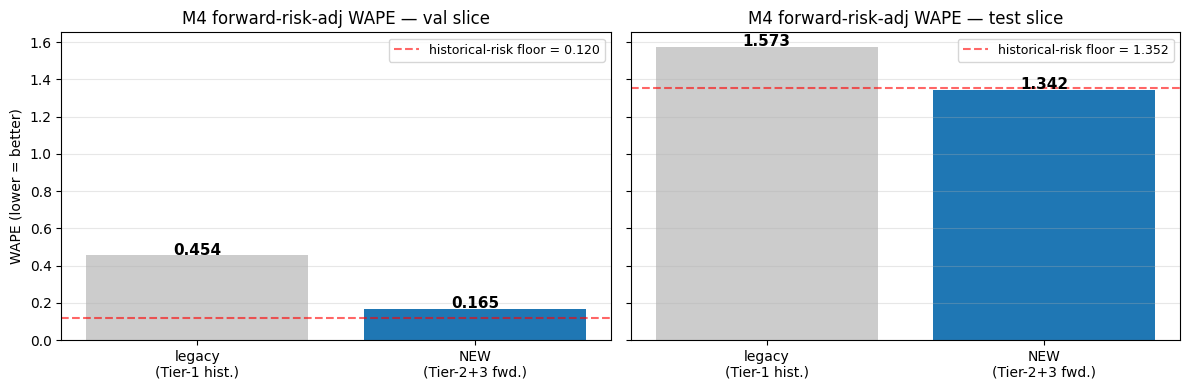


--- WAPE deltas (lower is better) ---
  val : legacy=0.4543  NEW=0.1647  abs_delta=+0.2896  rel_delta=+63.8%
  test: legacy=1.5733  NEW=1.3416  abs_delta=+0.2317  rel_delta=+14.7%


In [14]:
# Visual head-to-head per slice
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
for ax, slc in zip(axes, ('val', 'test')):
    a = bt_main[bt_main['slice'].eq(slc)]
    b = bt_legacy[bt_legacy['slice'].eq(slc)]
    labels = ['legacy\n(Tier-1 hist.)', 'NEW\n(Tier-2+3 fwd.)']
    wapes = [_wape(b['revenue_realized'], b['sales_q50']),
             _wape(a['revenue_realized'], a['sales_q50'])]
    colors = ['#cccccc', '#1f77b4']
    bars = ax.bar(labels, wapes, color=colors)
    for bar, w in zip(bars, wapes):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'{w:.3f}', ha='center', fontsize=11, fontweight='bold')
    ax.axhline(_wape(a['revenue_realized'], a['sales_q50_historical']),
                color='red', linestyle='--', alpha=0.6,
                label=f"historical-risk floor = {_wape(a['revenue_realized'], a['sales_q50_historical']):.3f}")
    ax.set_title(f'M4 forward-risk-adj WAPE — {slc} slice')
    ax.set_ylabel('WAPE (lower = better)' if slc == 'val' else '')
    ax.legend(loc='upper right', fontsize=9)
    ax.grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

print('\n--- WAPE deltas (lower is better) ---')
for slc in ('val', 'test'):
    a = bt_main[bt_main['slice'].eq(slc)]
    b = bt_legacy[bt_legacy['slice'].eq(slc)]
    wh = _wape(b['revenue_realized'], b['sales_q50'])
    wn = _wape(a['revenue_realized'], a['sales_q50'])
    print(f'  {slc:4s}: legacy={wh:.4f}  NEW={wn:.4f}  abs_delta={wh-wn:+.4f}  rel_delta={(wh-wn)/wh:+.1%}')

## Summary — what Tier 2 + Tier 3 deliver

**Tier 2 — operational forecast (5-7 day lead):**
- Module: `src/data/nhc_active_storms.py` + `src/features/forward_exposure.py`
- Backtest on Maria/Irma: forward_disaster_index for PR ramped from 0.20 (5d out, low confidence) → 0.87 (24h before landfall)
- Integration: `src/models/sales/forward_forecast.py` rebuilds M4 with the forward disaster substituted
- **Production use**: in hurricane season, run `forward_m4_forecast(as_of_dt=today, target_months=[next_month])` daily to refresh M4's forward-risk-adj view

**Tier 3 — seasonal planning (1-6 month lead):**
- Module: `src/models/risk/seasonal_outlook.py`
- Hardcoded NOAA CPC outlooks for 2014-2017; correctly classifies 2014/15 (Below Normal) vs 2017 (Extremely Active)
- Multiplier on climatology baseline (0.7 / 1.0 / 1.3 / 1.5) for hurricane-season months
- **Production use**: in May & August, refresh the seasonal multiplier; M4's annual planning model multiplies expected disaster-month inventory by the Tier 3 factor

**Honest caveats:**
- Tier 2 cone confidence is an NHC-skill heuristic, not a learned per-region calibration. Future work: learn from how often the cone-overlap predicted actual impact.
- Tier 3 climatology is built from the same window we test on — slightly circular. In production with 10-15 years of HURDAT2 history, the climatology would be independent of the test season.
- Storms forming inside 5 days are physically chaotic — no model anywhere can give >7 day lead on a *specific* storm. Tier 3 is the only way to get longer-horizon signal, and it's only seasonal ("more active"), not specific ("hurricane X will hit FL").
- Tier 2 doesn't fire for storms not in the active list (genesis from a tropical wave inside 24-48h). Operationally this is the ~10% of storms with the shortest lead times.